# Notes 
You have mapped out the exact DNA of the logistic regression algorithm perfectly. Your sequence is completely correct.
Here is that exact chain of logic laid out step-by-step, showing how each link connects to the next to go from raw data to the final optimized model.
## 1. The Raw Data

* The Input: You start with your dataset containing features ($x$) and binary targets ($y$, which are either 0 or 1). [1, 2, 3] 

## 2. The Linear Blueprint (The Boundary)

* The Logic: Just like linear regression, you want to find a best-fit line.
* The Action: You calculate the standard linear equation:
$$z = \beta_0 + \beta_1 $$

## 3. The Activation (The Sigmoid Squash)

* The Logic: A standard line outputs numbers from negative infinity to positive infinity, which makes no sense for binary categories.
* The Action: You pass that line equation into the Sigmoid Function:       

$ p = \frac{1}{1 + e^{-z}} $ 
* The Result: This squashes the output down, transforming the linear value into a valid probability ($p$) between 0 and 1. [6, 7, 8, 9, 10] 

## 4. The Goal (Maximum Likelihood Estimation)

* The Logic: You want a mathematical way to say, "Find the weights that make the actual true labels ($y$) the most likely outcome."
* The Action: You use Maximum Likelihood Estimation (MLE). You multiply all the predicted probabilities together to get the total likelihood of your dataset. [11, 12, 13] 

## 5. The Mathematical Shortcut (The Log Likelihood)

* The Logic: Multiplying thousands of tiny probabilities together creates numbers so small that computers cannot handle them (floating-point underflow). Also, calculus on products is incredibly difficult.
* The Action: You take the natural log ($\ln$) of those probabilities.
* The Result: The log transforms multiplication into simple addition, turning the complex product into the Log-Likelihood function. [14, 15, 16] 

## 6. The Inversion (Cost Minimization)

* The Logic: Optimization algorithms are built to find the minimum of a valley, not the maximum of a hill.
* The Action: You flip the sign by multiplying the Log-Likelihood by $-1$.
* The Result: This turns it into the Negative Log-Likelihood (also known as Binary Cross-Entropy Loss or Log Loss). Now, maximizing likelihood means minimizing this loss. [17, 18, 19, 20, 21] 

## 7. The Optimization (Gradient Descent)

* The Logic: You need to find the lowest point of this loss curve.
* The Action: You use Gradient Descent. You calculate the partial derivatives (gradients) of the loss with respect to your weights.
* The Step: You take small steps opposite to the gradient to continuously tweak $\beta_0$ and $\beta_1$ until the loss stops shrinking. [22, 23] 

## The Complete Logic Loop

[Data (x, y)] 
     ↓
[Linear Line (z)] 
     ↓
[Sigmoid Function] 
     ↓
[Probability (p)] 
     ↓
[Maximum Likelihood] 
     ↓
[Log Likelihood] 
     ↓
[Negative Log Loss] 
     ↓
[Gradient Descent Updates] → Loop back to Linear Line until optimized

Would you like to write a quick Python script to watch this chain of logic update the weights in real-time, or should we look at how multi-class classification changes this chain?


```mermaid
graph TD
    %% Define Nodes
    A["Data <br> <b>(x, y)</b>"] --> B["Linear Combination <br> <b>z = wx + b</b>"]
    B --> C["Sigmoid Function <br> <b>σ(z) = 1 / (1 + e⁻ᶻ)</b>"]
    C --> D["Predicted Probability <br> <b>p = P(y=1|x)</b>"]
    D --> E["Maximum Likelihood Estimation <br> <b>L(w,b) = ∏ [pʸ * (1-p)¹⁻ʸ]</b>"]
    E --> F["Log-Likelihood <br> <b>log L(w,b)</b>"]
    F --> G["Negative Log-Loss (Cost Function) <br> <b>J(w,b) = -log L(w,b)</b>"]
    G --> H["Gradient Descent Updates <br> <b>w := w - α(∂J/∂w)</b> <br> <b>b := b - α(∂J/∂b)</b>"]
    
    %% Loop Back
    H -->|Update Weights & Bias| B

    

```

 a simple Logistic Regression model and a Perceptron are nearly identical, but they diverge significantly in how they handle probabilities and optimization.

```mermaid
graph LR
    %% Structural Path
    X["Inputs (x)"] -->|Weights & Bias| Lin["Linear Core (z)"]

    %% Split Path
    Lin -->|Hard Step Function| Perc["Perceptron<br><b style='color:#ff9100;'>Output: 0 or 1</b>"]
    Lin -->|Soft Sigmoid Curve| LogReg["Logistic Regression<br><b style='color:#00e676;'>Output: P(y=1)</b>"]

    %% Dark Theme Styles
    classDef default fill:#1e1e1e,stroke:#aaaaaa,stroke-width:1.5px,color:#ffffff;
    classDef percStyle fill:#432808,stroke:#ff9100,stroke-width:2px,color:#ffffff;
    classDef logStyle fill:#1b4314,stroke:#00e676,stroke-width:2px,color:#ffffff;
    
    class Perc percStyle;
    class LogReg logStyle;
    linkStyle default stroke:#00b0ff,stroke-width:2px;

```

# logistic regression interactive

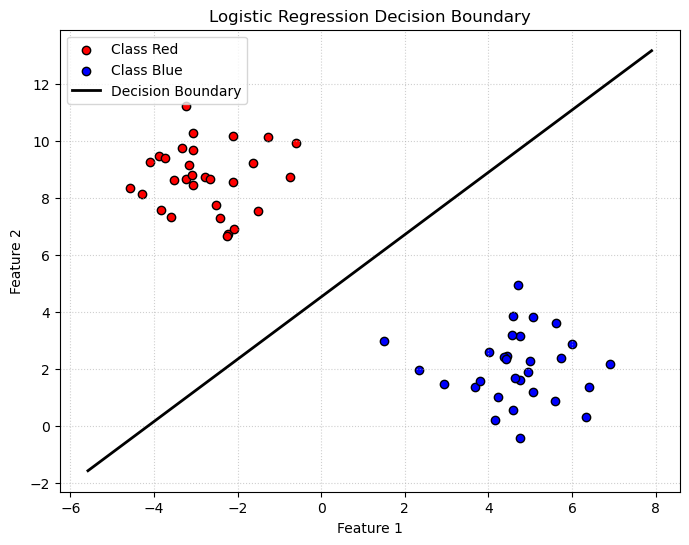

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression

# 1. Generate a synthetic 2D dataset with 2 classes
X, y = make_blobs(n_samples=60, centers=2, random_state=42, cluster_std=1.2)

# 2. Fit the Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

# 3. Extract the weights and intercept for the decision boundary
# Equation: w0*x + w1*y + intercept = 0  ->  y = (-w0*x - intercept) / w1
w = model.coef_[0]
b = model.intercept_[0]

# Generate X values for the line
x_bounds = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])
y_bounds = (-w[0] * x_bounds - b) / w[1]

# 4. Plot the dataset and decision boundary
plt.figure(figsize=(8, 6))

# Plot Red Class (label 0) and Blue Class (label 1)
plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', edgecolors='k', label='Class Red')
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', edgecolors='k', label='Class Blue')

# Plot the separating line
plt.plot(x_bounds, y_bounds, color='black', linewidth=2, label='Decision Boundary')

plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from ipywidgets import interact, FloatSlider

# 1. Generate a synthetic 2D dataset with 2 classes
X, y = make_blobs(n_samples=60, centers=2, random_state=42, cluster_std=1.2)

# 2. Fit the Logistic Regression model to find optimal values
model = LogisticRegression()
model.fit(X, y)

# Extract optimal weights and bias
w_opt = model.coef_[0]
b_opt = model.intercept_[0]

# Define bounds for plotting lines
x_bounds = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])

# 3. Define the interactive plotting function
def plot_interactive_boundary(w0, w1, bias):
    plt.figure(figsize=(9, 6))
    
    # Plot dataset
    plt.scatter(X[y == 0, 0], X[y == 0, 1], color='red', edgecolors='k', label='Class Red')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', edgecolors='k', label='Class Blue')
    
    # Plot optimal Logistic Regression boundary (fixed reference)
    y_opt = (-w_opt[0] * x_bounds - b_opt) / w_opt[1]
    plt.plot(x_bounds, y_opt, color='black', linestyle=':', linewidth=1.5, label='Optimal Boundary')
    
    # Plot custom interactive boundary (avoids division by zero)
    if w1 != 0:
        y_custom = (-w0 * x_bounds - bias) / w1
        plt.plot(x_bounds, y_custom, color='green', linewidth=2.5, label='Your Boundary')
    
    # Dynamic styling
    plt.title(f'Interactive Linear Boundary: {w0:.2f}*x1 + {w1:.2f}*x2 + {bias:.2f} = 0')
    plt.xlabel('Feature 1 ($x_1$)')
    plt.ylabel('Feature 2 ($x_2$)')
    plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# 4. Create sliders initialized near the optimal values
interact(
    plot_interactive_boundary,
    w0=FloatSlider(min=-5.0, max=5.0, step=0.1, value=float(w_opt[0]), description=r'w0 ($x_1$ weight)'),
    w1=FloatSlider(min=-5.0, max=5.0, step=0.1, value=float(w_opt[1]), description=r'w1 ($x_2$ weight)'),
    bias=FloatSlider(min=-10.0, max=10.0, step=0.2, value=float(b_opt), description='bias ($b$)')
)

interactive(children=(FloatSlider(value=0.8956450256213011, description='w0 ($x_1$ weight)', max=5.0, min=-5.0…

<function __main__.plot_interactive_boundary(w0, w1, bias)>

# simple logistic regression interactive 

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import LogisticRegression
from ipywidgets import interact, FloatSlider

# 1. Generate a synthetic 1D dataset (1 numerical feature, 2 classes)
X, y = make_blobs(n_samples=60, centers=2, n_features=1, random_state=42, cluster_std=1.5)
X = X.ravel()  # Flatten to a 1D array

# 2. Fit the Logistic Regression model to find optimal values
model = LogisticRegression()
model.fit(X.reshape(-1, 1), y)

# Extract optimal weight (w) and bias (b)
w_opt = model.coef_[0][0]
b_opt = model.intercept_[0]
threshold_opt = -b_opt / w_opt

# Generate smooth X values for plotting the probability curve
x_curve = np.linspace(X.min() - 2, X.max() + 2, 300)

# Sigmoid function helper
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 3. Define the interactive plotting function
def plot_1d_boundary(w, bias):
    plt.figure(figsize=(10, 5))
    
    # Plot dataset points at y=0 and y=1
    plt.scatter(X[y == 0], y[y == 0], color='red', edgecolors='k', s=50, zorder=3, label='Class Red (0)')
    plt.scatter(X[y == 1], y[y == 1], color='blue', edgecolors='k', s=50, zorder=3, label='Class Blue (1)')
    
    # Plot your custom interactive sigmoid curve
    y_curve_custom = sigmoid(w * x_curve + bias)
    plt.plot(x_curve, y_curve_custom, color='green', alpha=0.4, linestyle='--', label='Your Prob Curve')
    
    # Plot your custom interactive decision boundary threshold (where w*x + b = 0)
    if w != 0:
        threshold_custom = -bias / w
        plt.axvline(x=threshold_custom, color='green', linewidth=2.5, label='Your Decision Boundary')
    
    # Plot optimal model boundary as a fixed reference line
    plt.axvline(x=threshold_opt, color='black', linestyle=':', linewidth=1.5, label='Optimal Boundary')
    
    # Formatting
    plt.title(f'1D Logistic Regression: Boundary at $X$ = {-bias/w:.2f}' if w != 0 else '1D Logistic Regression')
    plt.xlabel('Numerical Feature ($X$)')
    plt.ylabel('Probability / Class')
    plt.ylim(-0.1, 1.1)
    plt.xlim(x_curve.min(), x_curve.max())
    plt.legend(loc='center right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# 4. Create sliders initialized near the optimal values
interact(
    plot_1d_boundary,
    w=FloatSlider(min=-5.0, max=5.0, step=0.1, value=float(w_opt), description='weight '),
    bias=FloatSlider(min=-10.0, max=10.0, step=0.2, value=float(b_opt), description='bias ')
)


interactive(children=(FloatSlider(value=1.1240826510165385, description='weight ', max=5.0, min=-5.0), FloatSl…

<function __main__.plot_1d_boundary(w, bias)>

# logistic regression in sklearn 

We know we data have X |Y         
simple linear regression : $ y = mx + b $               
in logistic regression we use the sigmoid
 $ y = \frac{1}{1 + e^{mx + b}}  $

we have slope and intercept but in different context

In [1]:
import pandas as pd  

Hamara paas data ha runner ka ki vo 1 week me kitna miles run kiya .            
We ask Questions to each runner  whether they have completed a 50-mile ultramarathon  . yes or no       
and runner response  with  “yes” or “no”. 

In [50]:
data= {
    'miles_per_week': [37,39,46,51,88,17,18,20,21,22,23,24,25,27,28,29,30,31,32,33,34,38,40,42,57,68,35,36,41,43,45,47,49,50,52,53,54,55,56,58,59,60,61,63,64,65,66,69,70,72,73,75,76,77,78,80,81,82,83,84,85,86,87,89,91,92,93,95,96,97,98,99,100,101,102,103,104,105,106,107,109,110,111,113,114,115,116,116,118,119,120,121,123,124,126,62,67,74,79,90,112],
'completed_50m_ultra': ['no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','yes','yes','yes','yes','no','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes',]
}
df = pd.DataFrame(data)
df

,miles_per_week,completed_50m_ultra
0,37,no
1,39,no
2,46,no
3,51,no
4,88,no
...,...,...
96,67,yes
97,74,yes
98,79,yes
99,90,yes


So input we have numerical data and output is binary cateogrical data .         
but machine learning algorithum do not understand words they understand number 
so we need to convert the binary words yes or no into number 1 or 0

In [5]:
from sklearn.preprocessing import OrdinalEncoder

In [6]:
finished_race = ['no','yes']

In [7]:
encoding = OrdinalEncoder(categories=[finished_race])

In [52]:
df['completed_50m_ultra']= encoding.fit_transform(df[['completed_50m_ultra']])

In [53]:
df

,miles_per_week,completed_50m_ultra
0,37,0.0
1,39,0.0
2,46,0.0
3,51,0.0
4,88,0.0
...,...,...
96,67,1.0
97,74,1.0
98,79,1.0
99,90,1.0


In [17]:
# now visualise the data 
from matplotlib import pyplot as plt

draw a scatter plot 
x-axis shows the miles_per_week (numerical values).     

y-axis shows the encoded values of completed_50m_ultra.     

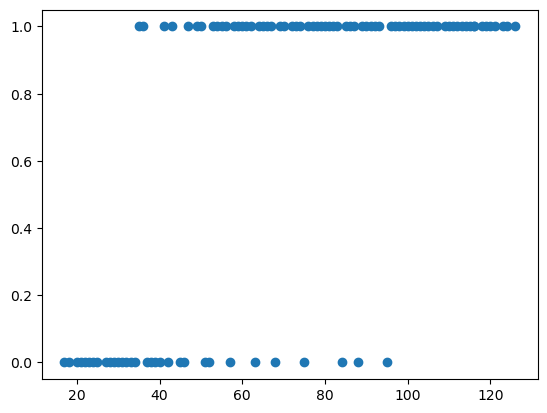

In [ ]:
plt.scatter(df.miles_per_week,df.completed_50m_ultra, )

In [20]:
import seaborn as sns

<Axes: xlabel='completed_50m_ultra', ylabel='count'>

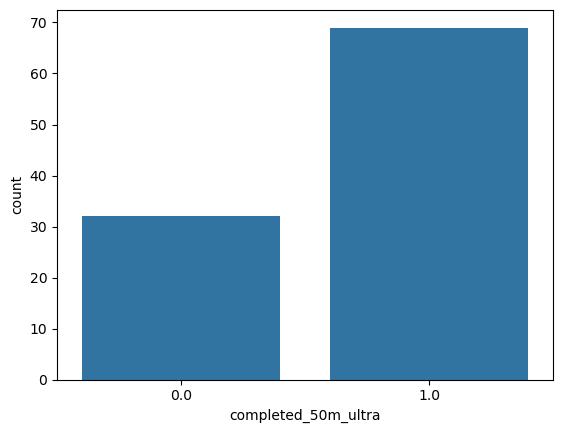

In [21]:
sns.countplot(x= 'completed_50m_ultra',data=df)


In [24]:
df.columns

Index(['miles_per_week', 'completed_50m_ultra'], dtype='object')

<Axes: xlabel='miles_per_week', ylabel='completed_50m_ultra'>

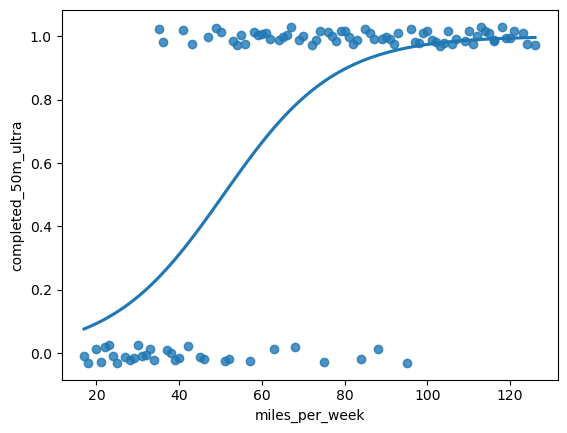

In [ ]:
sns.regplot(data =df ,
            x='miles_per_week',y='completed_50m_ultra' ,
            logistic=True,
            y_jitter=0.03,
            ci=None,
    
            )


idea : in plotly data viz we study univarite . their is strip plot to vislualsie one dimension data 

In [47]:
import plotly.express as px

In [44]:
df.columns

Index(['miles_per_week', 'completed_50m_ultra'], dtype='object')

In [46]:
px.strip(data_frame=df, x='miles_per_week',color='completed_50m_ultra')

In [48]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.linear_model import LogisticRegression

# 1. Mock Data (Miles per week vs Ultra Completed)
df = pd.DataFrame({
    'miles_per_week': [10, 15, 22, 28, 30, 32, 40, 45, 52, 60],
    'completed_50m_ultra': [0, 0, 0, 0, 1, 0, 1, 1, 1, 1]
})

# 2. Fit simple 1D Logistic Regression
X = df[['miles_per_week']]
y = df['completed_50m_ultra']
model = LogisticRegression().fit(X, y)

# 3. Calculate the boundary point: x = -bias / weight
weight = model.coef_[0][0]
bias = model.intercept_[0]
decision_boundary = -bias / weight

# 4. Generate the base strip plot
fig = px.strip(
    data_frame=df, 
    x='miles_per_week', 
    y='completed_50m_ultra', # Keeps points aligned horizontally
    color='completed_50m_ultra',
    color_discrete_map={0: 'red', 1: 'blue'},
    title=f"Logistic Regression Boundary Cutoff at {decision_boundary:.1f} Miles"
)

# 5. Overlay the green decision boundary line simply
fig.add_vline(
    x=decision_boundary, 
    line_width=3, 
    line_dash="dash", 
    line_color="green"
)

fig.show()


In [32]:
X = df.iloc[:, 0:1] # feature
y = df.iloc[:,1] # target

In [33]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,train_size=0.8, random_state=11)

In [34]:
print(X_train.shape)
print(X_test.shape)

(80, 1)
(21, 1)


In [35]:
from sklearn.linear_model import LogisticRegression

In [37]:
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [38]:
y_pred = model.predict(X_test)

In [39]:
model.score(X_test,y_test)

0.9047619047619048

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy_score(y_test,y_pred)

0.9047619047619048

In [41]:
print(confusion_matrix(y_test, y_pred))

[[ 5  1]
 [ 1 14]]


In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83         6
         1.0       0.93      0.93      0.93        15

    accuracy                           0.90        21
   macro avg       0.88      0.88      0.88        21
weighted avg       0.90      0.90      0.90        21



Keep learning and growing 

In [60]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import LogisticRegression

def plot_1d_logistic_boundary(X, y, feature_name="Feature X"):
    """
    Fits a 1D Logistic Regression model and visualizes data points, 
    shaded decision regions, and the prediction curve using Plotly.
    
    Parameters:
    -----------
    X : array-like, shape (n_samples,) or (n_samples, 1)
        The 1D numerical input feature.
    y : array-like, shape (n_samples,)
        The binary categorical targets (0 and 1).
    feature_name : str, optional
        Label for the horizontal axis. Default is "Feature X".
    """
    # 1. Format input data structures
    X_arr = np.array(X).reshape(-1, 1)
    y_arr = np.array(y).ravel()
    
    df = pd.DataFrame({
        'X_val': X_arr.ravel(),
        'y_val': y_arr
    })
    
    # Map class integers to high-contrast categorical text labels
    df['Class'] = df['y_val'].map({0: 'Orange Class (0)', 1: 'Blue Class (1)'})
    
    # 2. Fit the 1D Logistic Regression model
    model = LogisticRegression()
    model.fit(X_arr, y_arr)
    
    w = model.coef_[0][0]
    b = model.intercept_[0]
    
    # Guard against dividing by zero if the weight matches exactly 0
    decision_boundary = -b / w if w != 0 else 0
    
    # 3. Generate fine-grained coordinates for the curve space
    x_min, x_max = df['X_val'].min(), df['X_val'].max()
    x_padding = (x_max - x_min) * 0.1 if x_max != x_min else 1.0
    x_range = np.linspace(x_min - x_padding, x_max + x_padding, 400)
    
    # Extract prediction probability path for Class 1
    y_probs = model.predict_proba(x_range.reshape(-1, 1))[:, 1]
    
    # 4. Initialize strip plot layout base
    fig = px.strip(
        data_frame=df,
        x='X_val',
        y='y_val',
        color='Class',
        color_discrete_map={'Orange Class (0)': '#ff9100', 'Blue Class (1)': '#00b0ff'},
        title=f"1D Decision Boundary Plot (Cutoff threshold: {decision_boundary:.2f})",
        labels={'X_val': feature_name, 'y_val': 'Class / Prediction Probability'}
    )
    
    # 5. Tint background classification regions
    # Tint Orange for the region predicting Class 0
    fig.add_vrect(
        x0=x_range[0], x1=decision_boundary,
        fillcolor="#ff9100", opacity=0.08, line_width=0, layer="below"
    )
    # Tint Blue for the region predicting Class 1
    fig.add_vrect(
        x0=decision_boundary, x1=x_range[-1],
        fillcolor="#00b0ff", opacity=0.08, line_width=0, layer="below"
    )
    
    # 6. Overlay the solid green mathematical sigmoid line
    fig.add_trace(
        go.Scatter(
            x=x_range, y=y_probs,
            mode='lines',
            name='Logistic Curve',
            line=dict(color='#00e676', width=3)
        )
    )
    
    # 7. Add vertical boundary alignment mark
    fig.add_vline(
        x=decision_boundary,
        line_width=1.5,
        line_dash="dash",
        line_color="#333333"
    )
    
    # Lock coordinate frames to prevent layout jumping
    fig.update_layout(
        yaxis=dict(tickvals=[0, 0.5, 1], range=[-0.1, 1.1]),
        xaxis=dict(range=[x_range[0], x_range[-1]]),
        template="plotly_white",
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01)
    )
    
    fig.show()

plot_1d_logistic_boundary(X = df['miles_per_week'],y=df['completed_50m_ultra'])

In [63]:
import numpy as np
import pandas as pd

# Create a mock 1D dataset (e.g., Exam Scores vs Passing/Failing)
np.random.seed(7)
scores = np.random.uniform(30, 100, 50)
prob = 1 / (1 + np.exp(-(0.15 * (scores - 65))))
passed = np.random.binomial(1, prob)

# Put everything into a clean DataFrame
df = pd.DataFrame({'Score': scores, 'Actual_Class': passed})

# Map 0 to Orange and 1 to Blue for clear labeling
df['Actual_Color'] = df['Actual_Class'].map({0: 'Orange (Fail)', 1: 'Blue (Pass)'})


from sklearn.linear_model import LogisticRegression

# Fit the 1D model
X = df[['Score']]
y = df['Actual_Class']
model = LogisticRegression().fit(X, y)

# Find the exact decision threshold point (where probability is exactly 0.5)
w = model.coef_[0][0]
b = model.intercept_[0]
boundary_cutoff = -b / w

# Predict labels for our actual data points to check for mistakes
df['Predicted_Class'] = model.predict(X)
df['Is_Correct'] = df['Actual_Class'] == df['Predicted_Class']


import plotly.express as px

fig = px.strip(
    data_frame=df,
    x='Score',
    y='Actual_Class',
    color='Actual_Color',
    color_discrete_map={'Orange (Fail)': '#ff9100', 'Blue (Pass)': '#00b0ff'},
    title=f"Point Decision Boundary (Cutoff Threshold: {boundary_cutoff:.1f})",
    labels={'Score': 'Test Score (Numerical Variable)', 'Actual_Class': 'True Class Outcome'}
)

fig.show()


In [64]:
import plotly.graph_objects as go

# Create smooth X values stretching across the plot
x_curve = np.linspace(df['Score'].min() - 5, df['Score'].max() + 5, 300)
# Extract the prediction probabilities for Class 1 (Blue)
y_curve_probs = model.predict_proba(x_curve.reshape(-1, 1))[:, 1]

# Append the green probability line to our existing figure
fig.add_trace(
    go.Scatter(
        x=x_curve, y=y_curve_probs,
        mode='lines',
        name='Logistic Sigmoid Curve',
        line=dict(color='#00e676', width=3) # Vibrant green color
    )
)


c:\Users\sumit\miniconda3\envs\my_env\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning:

X does not have valid feature names, but LogisticRegression was fitted with feature names



In [65]:
# Add the vertical threshold marker line
fig.add_vline(
    x=boundary_cutoff,
    line_width=2,
    line_dash="dash",
    line_color="#333333"
)

# Clean up layout axes and display the interactive plot
fig.update_layout(
    yaxis=dict(tickvals=[0, 0.5, 1], range=[-0.1, 1.1]),
    template="plotly_white"
)

fig.show()


# Decesion boundary 

In [ ]:
from mlxtend.plotting import plot_decision_regions
# 1. Generate a synthetic 2D dataset with 2 classes
X, y = make_blobs(n_samples=60, centers=2, random_state=42, cluster_std=1.2)

# 2. Fit the Logistic Regression model
model = LogisticRegression()
model.fit(X, y)

plot_decision_regions(X, y, clf=model, legend=2)
plt.xlabel('feature1')
plt.ylabel('feature2')
plt.show()